In [155]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns',None)
pd.set_option('display.width',1000)
import warnings
warnings.filterwarnings('ignore')
import plotly.express as px
import folium
from folium import Circle
from geopy import Nominatim
from sklearn.preprocessing import MinMaxScaler
from IPython.display import display

In [156]:
df=pd.read_csv('step2_cost_of_living.csv')

In [157]:
df.sample()

,location,city,country,"Meal, Inexpensive Restaurant","Meal for 2 People, Mid-range Restaurant, Three-course",McMeal at McDonalds (or Equivalent Combo Meal),Domestic Beer (0.5 liter draught),Imported Beer (0.33 liter bottle),Imported Beer (0.33 liter bottle).1,Coke/Pepsi (0.33 liter bottle),Water (0.33 liter bottle),"Milk (regular), (1 liter)",Loaf of Fresh White Bread (500g),Eggs (regular) (12),Local Cheese (1kg),Water (1.5 liter bottle),Bottle of Wine (Mid-Range),Domestic Beer (0.5 liter bottle),Imported Beer (0.33 liter bottle).2,Imported Beer (0.33 liter bottle).3,Cigarettes 20 Pack (Marlboro),One-way Ticket (Local Transport),"Chicken Breasts (Boneless, Skinless), (1kg)",Monthly Pass (Regular Price),Gasoline (1 liter),Volkswagen Golf,Apartment (1 bedroom) in City Centre,Apartment (1 bedroom) Outside of Centre,Apartment (3 bedrooms) in City Centre,Apartment (3 bedrooms) Outside of Centre,"Basic (Electricity, Heating, Cooling, Water, Garbage) for 85m2 Apartment",1 min. of Prepaid Mobile Tariff Local (No Discounts or Plans),"Internet (60 Mbps or More, Unlimited Data, Cable/ADSL)","Fitness Club, Monthly Fee for 1 Adult",Tennis Court Rent (1 Hour on Weekend),"Cinema, International Release, 1 Seat",1 Pair of Jeans (Levis 501 Or Similar),"1 Summer Dress in a Chain Store (Zara, H&M, ...)",1 Pair of Nike Running Shoes (Mid-Range),1 Pair of Men Leather Business Shoes,Price per Square Meter to Buy Apartment in City Centre,Price per Square Meter to Buy Apartment Outside of Centre,Average Monthly Net Salary (After Tax),"Mortgage Interest Rate in Percentages (%), Yearly, for 20 Years Fixed-Rate",Taxi Start (Normal Tariff),Taxi 1km (Normal Tariff),Taxi 1hour Waiting (Normal Tariff),Apples (1kg),Oranges (1kg),Potato (1kg),Lettuce (1 head),Cappuccino (regular),"Rice (white), (1kg)",Tomato (1kg),Banana (1kg),Onion (1kg),Beef Round (1kg) (or Equivalent Back Leg Red Meat),Toyota Corolla 1.6l 97kW Comfort (Or Equivalent New Car),"Preschool (or Kindergarten), Full Day, Private, Monthly for 1 Child","International Primary School, Yearly for 1 Child",latitude,longitude
37,"Beirut, Lebanon",Beirut,Lebanon,8.98,53.91,7.19,3.22,4.17,1.91,0.74,0.39,1.89,0.86,2.59,9.51,0.7,8.98,1.21,4.17,1.91,2.19,1.19,7.33,53.91,0.8,19766.67,719.35,393.83,1647.29,751.31,122.43,0.29,49.74,65.66,24.45,8.98,58.37,42.06,99.0,102.15,3589.98,1538.73,859.89,7.35,5.39,1.8,11.95,1.71,1.23,0.81,0.85,3.82,1.46,1.09,1.2,0.87,11.51,18766.59,348.27,4684.61,33.889226,35.502558


In [158]:
df.isna().sum()

location                                                                      0
city                                                                          0
country                                                                       0
Meal, Inexpensive Restaurant                                                  0
Meal for 2 People, Mid-range Restaurant, Three-course                         0
McMeal at McDonalds (or Equivalent Combo Meal)                                0
Domestic Beer (0.5 liter draught)                                             0
Imported Beer (0.33 liter bottle)                                             0
Imported Beer (0.33 liter bottle).1                                           0
Coke/Pepsi (0.33 liter bottle)                                                0
Water (0.33 liter bottle)                                                     0
Milk (regular), (1 liter)                                                     0
Loaf of Fresh White Bread (500g)        

In [159]:
df.columns

Index(['location', 'city', 'country', 'Meal, Inexpensive Restaurant', 'Meal for 2 People, Mid-range Restaurant, Three-course', 'McMeal at McDonalds (or Equivalent Combo Meal)', 'Domestic Beer (0.5 liter draught)', 'Imported Beer (0.33 liter bottle)', 'Imported Beer (0.33 liter bottle).1', 'Coke/Pepsi (0.33 liter bottle)', 'Water (0.33 liter bottle) ', 'Milk (regular), (1 liter)', 'Loaf of Fresh White Bread (500g)', 'Eggs (regular) (12)', 'Local Cheese (1kg)', 'Water (1.5 liter bottle)', 'Bottle of Wine (Mid-Range)', 'Domestic Beer (0.5 liter bottle)', 'Imported Beer (0.33 liter bottle).2', 'Imported Beer (0.33 liter bottle).3', 'Cigarettes 20 Pack (Marlboro)', 'One-way Ticket (Local Transport)', 'Chicken Breasts (Boneless, Skinless), (1kg)', 'Monthly Pass (Regular Price)', 'Gasoline (1 liter)', 'Volkswagen Golf', 'Apartment (1 bedroom) in City Centre', 'Apartment (1 bedroom) Outside of Centre', 'Apartment (3 bedrooms) in City Centre', 'Apartment (3 bedrooms) Outside of Centre',
       

In [160]:
#feature engineering
def food(row):
    return int(round(row[['Meal, Inexpensive Restaurant',  'Domestic Beer (0.5 liter draught)', 
                            'Imported Beer (0.33 liter bottle)', 'Coke/Pepsi (0.33 liter bottle)', 
                            'Water (0.33 liter bottle) ', 'Milk (regular), (1 liter)',
                            'Loaf of Fresh White Bread (500g)', 'Eggs (regular) (12)',
                            'Local Cheese (1kg)', 'Water (1.5 liter bottle)', 
                            'Bottle of Wine (Mid-Range)','Cigarettes 20 Pack (Marlboro)', 
                            'Chicken Breasts (Boneless, Skinless), (1kg)', 
                            'Apples (1kg)', 'Oranges (1kg)', 'Potato (1kg)', 'Lettuce (1 head)', 
                            'Cappuccino (regular)', 'Rice (white), (1kg)', 'Tomato (1kg)', 
                            'Banana (1kg)','Onion (1kg)', 
                            'Beef Round (1kg) (or Equivalent Back Leg Red Meat)']].mean()))
def travel(row):
    return int(round(row[['One-way Ticket (Local Transport)','Monthly Pass (Regular Price)',
                           'Taxi Start (Normal Tariff)', 'Taxi 1km (Normal Tariff)', 
                           'Taxi 1hour Waiting (Normal Tariff)',
                           'Gasoline (1 liter)',]].mean()))
def living(row):
    return int(round(row[['Volkswagen Golf',
                           'Apartment (1 bedroom) in City Centre', 
                           'Apartment (1 bedroom) Outside of Centre', 
                           'Apartment (3 bedrooms) in City Centre', 
                           'Apartment (3 bedrooms) Outside of Centre',
                           'Basic (Electricity, Heating, Cooling, Water, Garbage) for 85m2 Apartment',
                           'Price per Square Meter to Buy Apartment in City Centre', 
                           'Price per Square Meter to Buy Apartment Outside of Centre',
                           'Toyota Corolla 1.6l 97kW Comfort (Or Equivalent New Car)']].mean()))
def lifestyle(row):
    return int(round(row[['1 min. of Prepaid Mobile Tariff Local (No Discounts or Plans)', 
                      'Internet (60 Mbps or More, Unlimited Data, Cable/ADSL)', 
                      'Fitness Club, Monthly Fee for 1 Adult', 
                      'Tennis Court Rent (1 Hour on Weekend)', 
                      'Cinema, International Release, 1 Seat', 
                      '1 Pair of Jeans (Levis 501 Or Similar)', 
                      '1 Summer Dress in a Chain Store (Zara, H&M, ...)', 
                      '1 Pair of Nike Running Shoes (Mid-Range)', 
                      '1 Pair of Men Leather Business Shoes',
                      'Meal for 2 People, Mid-range Restaurant, Three-course',
                      'McMeal at McDonalds (or Equivalent Combo Meal)'
                      ]].mean()))
def education(row):
    return int(round(row[['Preschool (or Kindergarten), Full Day, Private, Monthly for 1 Child',
                      'International Primary School, Yearly for 1 Child']].mean()))
def income(row):
    return int(round(row[['Average Monthly Net Salary (After Tax)',
                      'Mortgage Interest Rate in Percentages (%), Yearly, for 20 Years Fixed-Rate']].mean()))

In [161]:
df['Food']=df.apply(food,axis=1)
df['Travel']=df.apply(travel,axis=1)
df['Living']=df.apply(living,axis=1)
df['Education']=df.apply(education,axis=1)
df['Income']=df.apply(income,axis=1)
df['Lifestyle']=df.apply(lifestyle,axis=1)

In [162]:
df.sample()

,location,city,country,"Meal, Inexpensive Restaurant","Meal for 2 People, Mid-range Restaurant, Three-course",McMeal at McDonalds (or Equivalent Combo Meal),Domestic Beer (0.5 liter draught),Imported Beer (0.33 liter bottle),Imported Beer (0.33 liter bottle).1,Coke/Pepsi (0.33 liter bottle),Water (0.33 liter bottle),"Milk (regular), (1 liter)",Loaf of Fresh White Bread (500g),Eggs (regular) (12),Local Cheese (1kg),Water (1.5 liter bottle),Bottle of Wine (Mid-Range),Domestic Beer (0.5 liter bottle),Imported Beer (0.33 liter bottle).2,Imported Beer (0.33 liter bottle).3,Cigarettes 20 Pack (Marlboro),One-way Ticket (Local Transport),"Chicken Breasts (Boneless, Skinless), (1kg)",Monthly Pass (Regular Price),Gasoline (1 liter),Volkswagen Golf,Apartment (1 bedroom) in City Centre,Apartment (1 bedroom) Outside of Centre,Apartment (3 bedrooms) in City Centre,Apartment (3 bedrooms) Outside of Centre,"Basic (Electricity, Heating, Cooling, Water, Garbage) for 85m2 Apartment",1 min. of Prepaid Mobile Tariff Local (No Discounts or Plans),"Internet (60 Mbps or More, Unlimited Data, Cable/ADSL)","Fitness Club, Monthly Fee for 1 Adult",Tennis Court Rent (1 Hour on Weekend),"Cinema, International Release, 1 Seat",1 Pair of Jeans (Levis 501 Or Similar),"1 Summer Dress in a Chain Store (Zara, H&M, ...)",1 Pair of Nike Running Shoes (Mid-Range),1 Pair of Men Leather Business Shoes,Price per Square Meter to Buy Apartment in City Centre,Price per Square Meter to Buy Apartment Outside of Centre,Average Monthly Net Salary (After Tax),"Mortgage Interest Rate in Percentages (%), Yearly, for 20 Years Fixed-Rate",Taxi Start (Normal Tariff),Taxi 1km (Normal Tariff),Taxi 1hour Waiting (Normal Tariff),Apples (1kg),Oranges (1kg),Potato (1kg),Lettuce (1 head),Cappuccino (regular),"Rice (white), (1kg)",Tomato (1kg),Banana (1kg),Onion (1kg),Beef Round (1kg) (or Equivalent Back Leg Red Meat),Toyota Corolla 1.6l 97kW Comfort (Or Equivalent New Car),"Preschool (or Kindergarten), Full Day, Private, Monthly for 1 Child","International Primary School, Yearly for 1 Child",latitude,longitude,Food,Travel,Living,Education,Income,Lifestyle
140,"Dublin, Ireland",Dublin,Ireland,15.0,60.0,8.0,5.8,5.5,2.69,1.8,1.59,0.95,1.42,2.79,7.51,1.41,12.0,2.42,5.5,2.69,12.7,3.0,8.35,125.0,1.44,24000.0,1692.24,1405.38,2964.36,2292.57,169.12,0.26,54.01,40.22,15.94,12.0,77.61,35.45,85.42,95.52,5457.63,4134.61,2531.16,3.43,4.0,1.35,26.73,2.09,2.3,1.56,0.96,3.2,1.59,2.77,1.9,1.14,9.24,25618.07,1041.49,8078.42,53.349379,-6.260559,5,27,7526,4560,1267,44


In [163]:
df.columns

Index(['location', 'city', 'country', 'Meal, Inexpensive Restaurant', 'Meal for 2 People, Mid-range Restaurant, Three-course', 'McMeal at McDonalds (or Equivalent Combo Meal)', 'Domestic Beer (0.5 liter draught)', 'Imported Beer (0.33 liter bottle)', 'Imported Beer (0.33 liter bottle).1', 'Coke/Pepsi (0.33 liter bottle)', 'Water (0.33 liter bottle) ', 'Milk (regular), (1 liter)', 'Loaf of Fresh White Bread (500g)', 'Eggs (regular) (12)', 'Local Cheese (1kg)', 'Water (1.5 liter bottle)', 'Bottle of Wine (Mid-Range)', 'Domestic Beer (0.5 liter bottle)', 'Imported Beer (0.33 liter bottle).2', 'Imported Beer (0.33 liter bottle).3', 'Cigarettes 20 Pack (Marlboro)', 'One-way Ticket (Local Transport)', 'Chicken Breasts (Boneless, Skinless), (1kg)', 'Monthly Pass (Regular Price)', 'Gasoline (1 liter)', 'Volkswagen Golf', 'Apartment (1 bedroom) in City Centre', 'Apartment (1 bedroom) Outside of Centre', 'Apartment (3 bedrooms) in City Centre', 'Apartment (3 bedrooms) Outside of Centre',
       

In [164]:
plot1=df[['country','Food', 'Travel', 'Living', 'Education', 'Income']].groupby('country',as_index=False).agg('mean')
plot1.style.background_gradient(cmap='Wistia')

,country,Food,Travel,Living,Education,Income
0,Albania,2.000000,5.000000,4157.000000,1225.000000,171.000000
1,Argentina,2.000000,3.000000,4346.000000,1638.000000,266.000000
2,Armenia,2.000000,3.000000,4390.000000,1581.000000,154.000000
3,Australia,4.400000,21.600000,4932.200000,5919.400000,1400.800000
4,Austria,4.000000,14.000000,6662.000000,8124.000000,951.000000
5,Azerbaijan,2.000000,2.000000,4164.000000,2933.000000,151.000000
6,Belarus,2.000000,3.000000,3932.000000,2874.000000,224.000000
7,Belgium,4.000000,15.000000,5773.000000,9519.000000,1146.000000
8,Bosnia And Herzegovina,2.000000,6.000000,4251.000000,1268.500000,231.500000
9,Brazil,2.000000,9.000000,5084.000000,5243.000000,240.000000


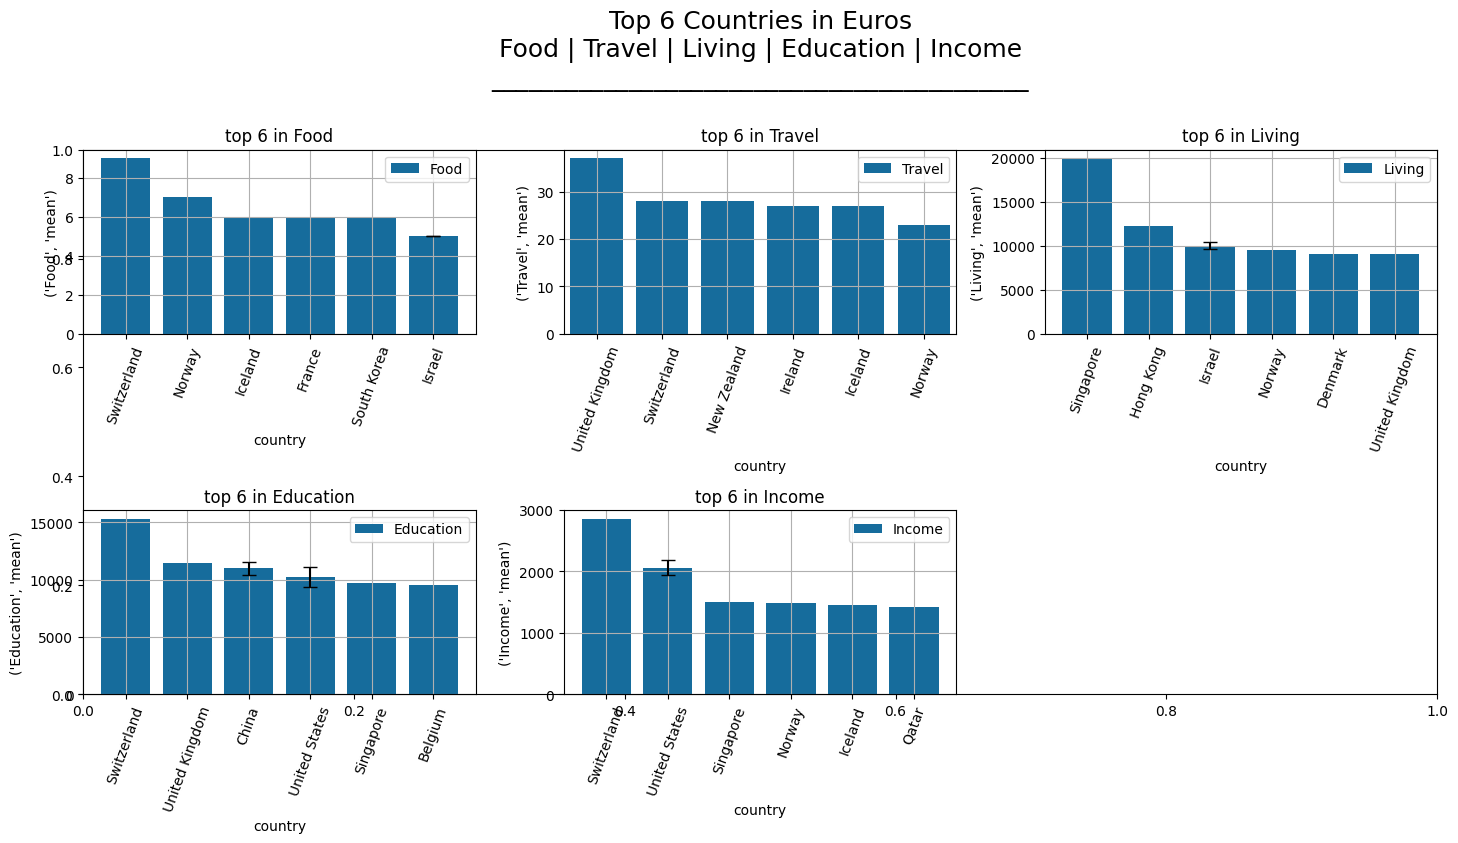

In [165]:
n=6
plot2=df[['country','Food', 'Travel', 'Living', 'Education', 'Income']].groupby('country',as_index=False).agg(['mean','sem'])
#print(plot2.columns)
cols=['Food', 'Travel', 'Living', 'Education', 'Income']

def plot_n_countries(data,columns,n,bottom=False):
    plt.figure(figsize=(15,9))
    title_multiplier=len('Food | Travel | Living | Education | Income')
    if bottom: plt.title(f"Bottom {n} in Euros\nFood | Travel | Living | Education | Income\n{title_multiplier*'_'}\n\n",fontsize=18)
    else: plt.title(f"Top {n} Countries in Euros\nFood | Travel | Living | Education | Income\n{title_multiplier*'_'}\n\n",fontsize=18)
    for ind, col in enumerate(cols):
        subplot2 = plot2.sort_values(by=(col, 'mean'), ascending=False)
        if bottom:
            subplot2=subplot2.tail(n)
        else: subplot2=subplot2.head(n)
        y = subplot2[(col, 'mean')]
        x = subplot2['country']
        error = subplot2[(col, 'sem')]
        plt.subplot(2, 3, ind + 1)
        ax = sns.barplot(x=x, y=y, label=col)
        # Add error bars manually if there are any non-NaN values
        if error.notna().any():
            ax.errorbar(
                range(len(x)), y, yerr=error, fmt='none', c='black', capsize=5
            )
        if bottom: plt.title(f"Bottom {n} {col}")
        else: plt.title(f"top {n} in {col}")
        plt.xticks(rotation=70)
        plt.grid()
    plt.tight_layout()
    plt.show()
plot_n_countries(plot2,cols,n)

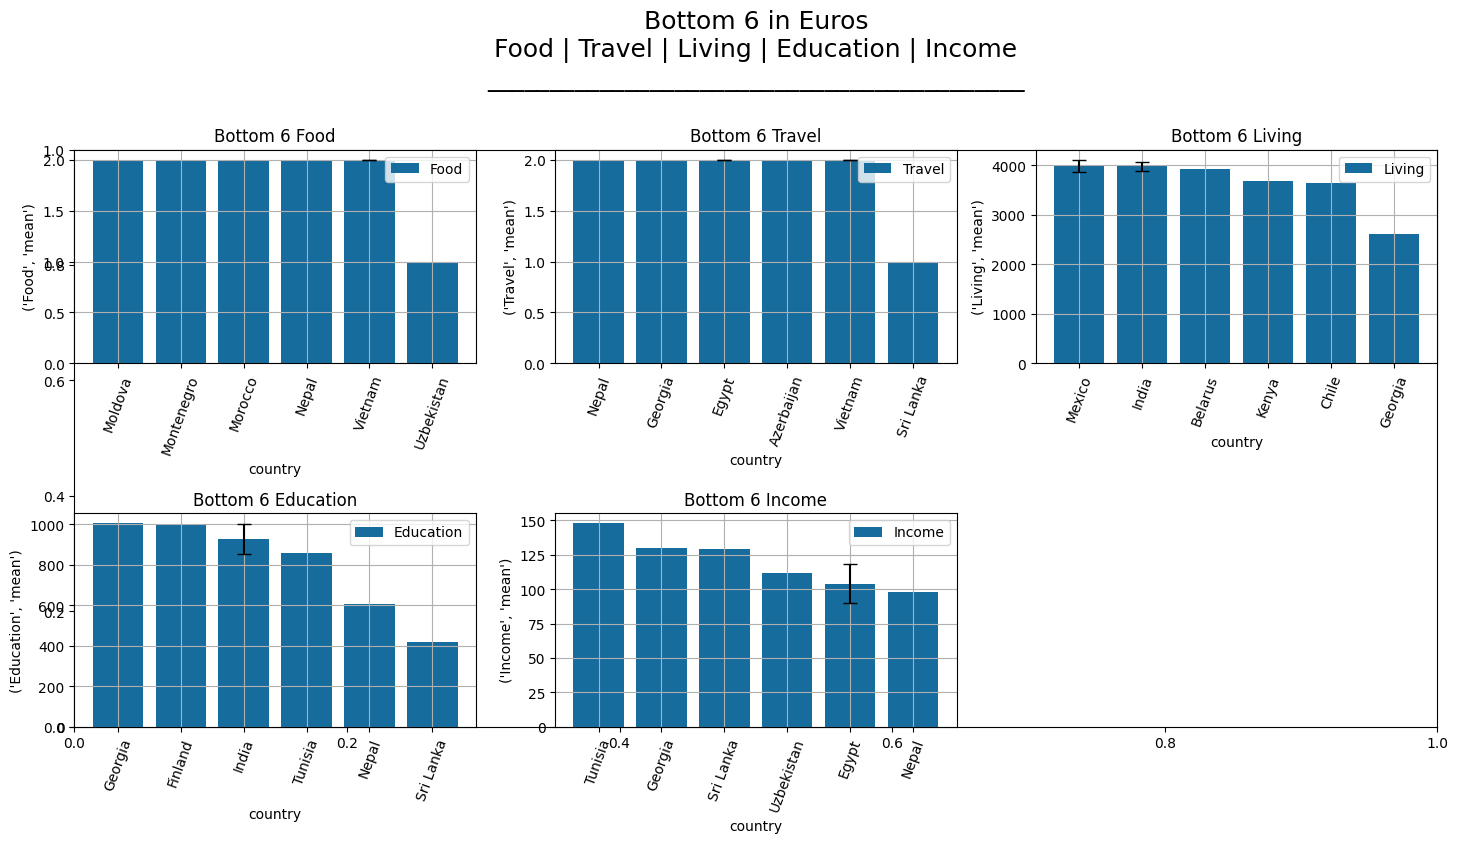

In [166]:
plot_n_countries(plot2,cols,n,bottom=True)

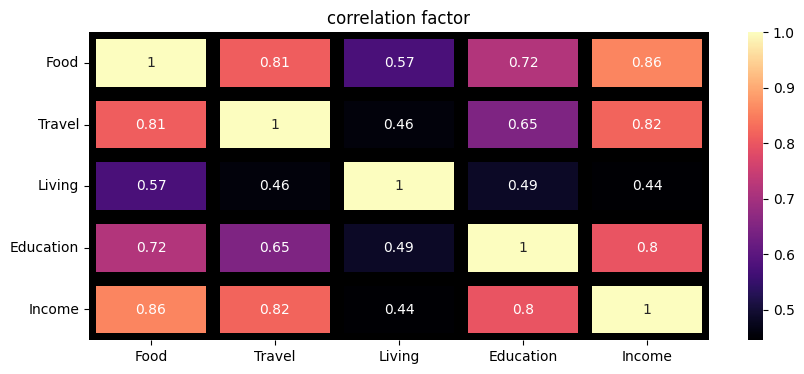

In [167]:
plt.rcParams['figure.figsize']=(10,4)
plt.style.use('seaborn-v0_8-colorblind')
sns.heatmap(df[['Food', 'Travel', 'Living', 'Education', 'Income']].corr(),
            annot=True,cmap='magma',linecolor='black',linewidths=10)
plt.title('correlation factor')
plt.yticks(rotation=0)
plt.show()

In [168]:
most_popular_countries=['United Kingdom','Australia','Germany','China','Russia']
plot3=df.loc[df['country'].isin(most_popular_countries)]
plot3=plot3[['location','Food', 'Travel', 'Living', 'Education', 'Income']].set_index('location').sort_values(by='Income',ascending=False)
plot3.style.background_gradient(cmap='autumn')

,Food,Travel,Living,Education,Income
location,,,,,
"Brisbane, Australia",5,22,4644,4910,1517
"Sydney, Australia",5,29,5781,6661,1511
"Melbourne, Australia",4,21,5218,7062,1398
"London, United Kingdom",4,37,9069,11423,1380
"Adelaide, Australia",4,16,4309,4606,1329
"Munich, Germany",4,17,7445,5867,1315
"Frankfurt, Germany",3,22,6871,6502,1310
"Hamburg, Germany",4,21,5940,7085,1267
"Perth, Australia",4,20,4709,6358,1249


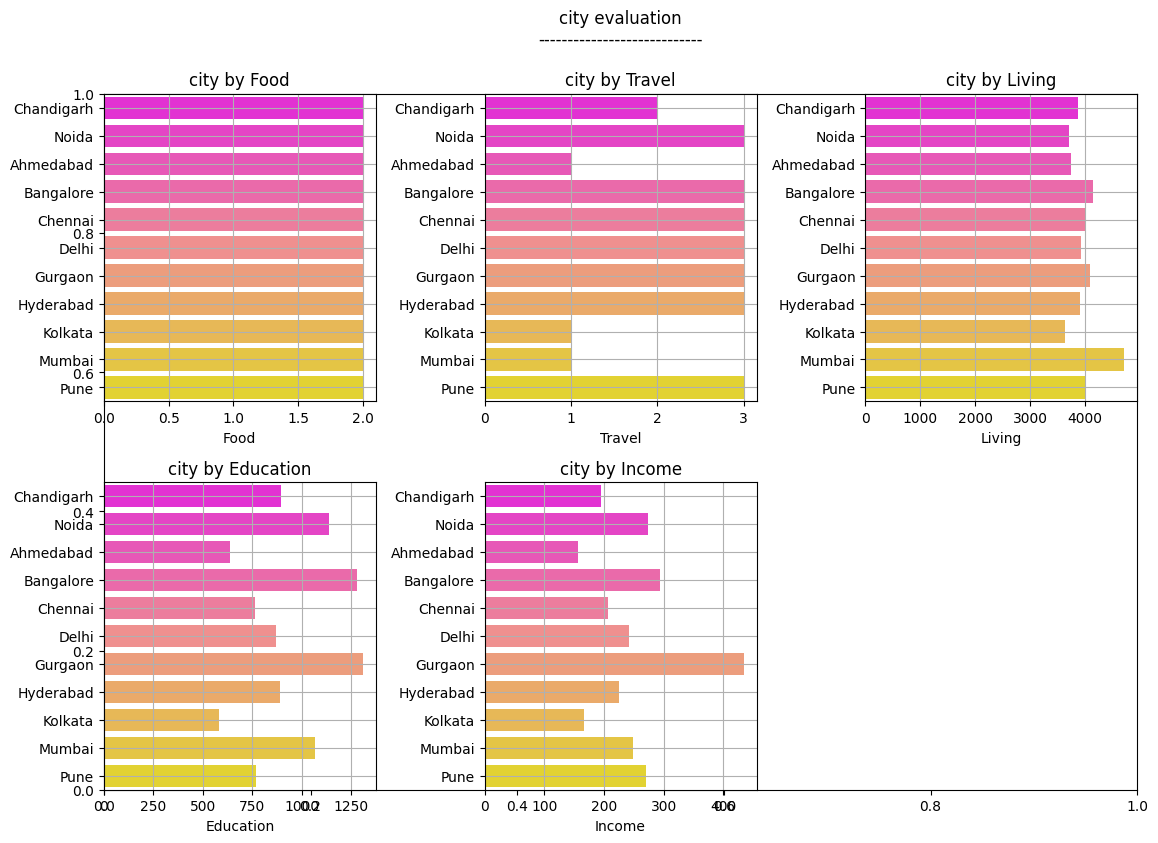

In [169]:
indian_cities=df.loc[df['country']=='India']['city'].to_list()
plot4_features=['Food', 'Travel', 'Living', 'Education', 'Income']
def filtered_plot(data,X_cols:list,y_col:str,y_vars:list,plot_size:int):
    """
    filters y_col to include only y_vars 
    plots a plot for each X_col
    """
    plots=len(X_cols)
    cols=int(min(np.ceil(np.sqrt(plots)),np.floor(19/plot_size)))
    rows=int(np.ceil(plots/cols))
    plt.rcParams['figure.figsize']=(cols*plot_size,1+(rows*plot_size))
    plt.title(f"{y_col} evaluation\n{2*len(y_col+'evaluation')*'-'}\n\n")
    for index,feature in enumerate(X_cols):
        data=data.loc[df[y_col].isin(y_vars)]
        x=data[feature]
        y=data[y_col]
        plt.subplot(rows,cols,index+1)
        sns.barplot(x=x,y=y,palette='spring')
        plt.ylabel('')
        plt.title(f"{y_col} by {feature}")
        plt.grid()
    plt.tight_layout()
    plt.show()

filtered_plot(df,plot4_features,'city',indian_cities,4)

In [170]:
plot5_vars=['Food','Travel','Living','Lifestyle','Education','Income']
plot5=df.copy()
mm=MinMaxScaler()
plot5[plot5_vars]=mm.fit_transform(plot5[plot5_vars])
plot5[plot5_vars].head().style.background_gradient(cmap='Set3')

,Food,Travel,Living,Lifestyle,Education,Income
0,0.125000,0.194444,0.139139,0.372549,0.139049,0.074890
1,0.125000,0.138889,0.161588,0.156863,0.177913,0.043424
2,0.125000,0.111111,0.155125,0.078431,0.121129,0.036816
3,0.500000,0.527778,0.252539,0.568627,0.032424,0.346759
4,0.125000,0.027778,0.082583,0.333333,0.057568,0.018250


In [171]:
plot5['Expenses']=plot5[['Food','Travel','Living','Lifestyle','Education']].mean(axis=1)
plot5['Total Score']=plot5['Income']-plot5['Expenses']
mn=plot5['Total Score'].min()
mx=plot5['Total Score'].max()
plot5['Total Score']=(plot5['Total Score']-mn)/(mx-mn)
#plot6=pd.merge(plot5,plot6,how='inner',on=['city','country'])
print('Ranked based on Income minus Expenses')
plot5[['country','city','Total Score']].sort_values(by='Total Score',ascending=False).head(10).style.background_gradient(cmap='rocket')

Ranked based on Income minus Expenses


,country,city,Total Score
100,United States,San Francisco,1.000000
38,United States,Austin,0.768535
53,United States,Dallas,0.745376
99,United States,San Diego,0.716865
102,United States,Seattle,0.707639
62,United States,Houston,0.639357
71,United States,Los Angeles,0.583810
69,United States,Las Vegas,0.554103
48,United States,Chicago,0.550365
86,United States,Phoenix,0.549113


In [172]:
print('Ranked based only on Income')
plot5[['country','city','Income']].sort_values(by='Income',ascending=False).head(10).style.background_gradient(cmap='rocket')

Ranked based only on Income


,country,city,Income
100,United States,San Francisco,1.000000
144,Switzerland,Zurich,0.870988
102,United States,Seattle,0.718376
78,United States,New York,0.706419
99,United States,San Diego,0.647892
53,United States,Dallas,0.633417
47,United States,Boston,0.622404
38,United States,Austin,0.617055
71,United States,Los Angeles,0.596602
48,United States,Chicago,0.557269


In [173]:
print('Ranked based on Income minus Expenses Ascending')
plot5[['country','city','Total Score']].sort_values(by='Total Score',ascending=True).head(10).style.background_gradient(cmap='rocket')

Ranked based on Income minus Expenses Ascending


,country,city,Total Score
126,Thailand,Bangkok,0.000000
129,Jordan,Amman,0.026134
134,Costa Rica,San Jose,0.086152
37,Lebanon,Beirut,0.089626
5,Italy,Milan,0.091933
125,China,Shanghai,0.102796
159,Ecuador,Quito,0.107706
119,Uruguay,Montevideo,0.109554
70,United Kingdom,London,0.112118
26,France,Paris,0.113234


In [174]:
print('Ranked based only on Expenses')
plot5[['country','city','Expenses']].sort_values(by='Expenses',ascending=False).head(10).style.background_gradient(cmap='rocket')

Ranked based only on Expenses


,country,city,Expenses
144,Switzerland,Zurich,0.774252
78,United States,New York,0.645366
39,Singapore,Singapore,0.589018
70,United Kingdom,London,0.578712
100,United States,San Francisco,0.574142
128,Iceland,Reykjavik,0.564689
50,Norway,Oslo,0.559896
47,United States,Boston,0.517388
26,France,Paris,0.492371
102,United States,Seattle,0.489643


In [175]:
print('Ranked based only on Expenses Ascending')
plot5[['country','city','Expenses']].sort_values(by='Expenses',ascending=True).head(10).style.background_gradient(cmap='rocket')

Ranked based only on Expenses Ascending


,country,city,Expenses
123,India,Kolkata,0.042646
106,India,Ahmedabad,0.044567
112,India,Chennai,0.056319
118,India,Hyderabad,0.060405
81,India,Chandigarh,0.066277
130,India,Pune,0.068069
110,India,Bangalore,0.071383
114,India,Delhi,0.072013
127,India,Mumbai,0.072297
83,India,Noida,0.072603


In [176]:
df.columns

Index(['location', 'city', 'country', 'Meal, Inexpensive Restaurant', 'Meal for 2 People, Mid-range Restaurant, Three-course', 'McMeal at McDonalds (or Equivalent Combo Meal)', 'Domestic Beer (0.5 liter draught)', 'Imported Beer (0.33 liter bottle)', 'Imported Beer (0.33 liter bottle).1', 'Coke/Pepsi (0.33 liter bottle)', 'Water (0.33 liter bottle) ', 'Milk (regular), (1 liter)', 'Loaf of Fresh White Bread (500g)', 'Eggs (regular) (12)', 'Local Cheese (1kg)', 'Water (1.5 liter bottle)', 'Bottle of Wine (Mid-Range)', 'Domestic Beer (0.5 liter bottle)', 'Imported Beer (0.33 liter bottle).2', 'Imported Beer (0.33 liter bottle).3', 'Cigarettes 20 Pack (Marlboro)', 'One-way Ticket (Local Transport)', 'Chicken Breasts (Boneless, Skinless), (1kg)', 'Monthly Pass (Regular Price)', 'Gasoline (1 liter)', 'Volkswagen Golf', 'Apartment (1 bedroom) in City Centre', 'Apartment (1 bedroom) Outside of Centre', 'Apartment (3 bedrooms) in City Centre', 'Apartment (3 bedrooms) Outside of Centre',
       

In [177]:
df=df.rename(columns={'Milk (regular), (1 liter)':'Milk', 
                      'Loaf of Fresh White Bread (500g)':'Bread', 
                      'Eggs (regular) (12)':'Eggs',
                      'Basic (Electricity, Heating, Cooling, Water, Garbage) for 85m2 Apartment':'Electricity_&_Water', 
                      'Internet (60 Mbps or More, Unlimited Data, Cable/ADSL)':'Internet',
                      'Taxi 1km (Normal Tariff)':'Taxi_Travel'})
df[['country','city','Milk','Bread','Eggs','Electricity_&_Water','Internet','Taxi_Travel']].sample()

,country,city,Milk,Bread,Eggs,Electricity_&_Water,Internet,Taxi_Travel
102,United States,Seattle,0.77,2.76,2.4,144.15,58.46,1.51


In [179]:
df[['Milk','Bread','Eggs','Electricity_&_Water','Internet','Taxi_Travel']].describe()

,Milk,Bread,Eggs,Electricity_&_Water,Internet,Taxi_Travel
count,160.000000,160.000000,160.000000,160.000000,160.000000,160.000000
mean,0.998937,1.197875,1.902813,107.106125,29.660875,0.922250
std,0.391720,0.760670,0.752520,51.553830,18.908249,0.709011
min,0.390000,0.100000,0.750000,18.560000,4.440000,0.140000
25%,0.710000,0.555000,1.377500,63.860000,12.832500,0.405000
50%,0.895000,1.020000,1.850000,102.465000,26.615000,0.630000
75%,1.170000,1.690000,2.352500,145.707500,43.317500,1.350000
max,2.640000,3.330000,5.330000,265.520000,93.290000,4.160000


In [206]:
from scipy.stats import percentileofscore
def print_top_n_rows(data,n:int,x_cols:list,y_cols:list,bottom=False):
    for i in y_cols:
        loop_data=data.copy()
        if not bottom: loop_data=loop_data.sort_values(by=i,ascending=False)
        else: loop_data=loop_data.sort_values(by=i,ascending=True)
        if not bottom:val=loop_data[i].iloc[n+1]
        else: val=loop_data[i].iloc[n]
        if not bottom: p_tile=percentileofscore(loop_data[i],val,kind='rank')
        else: p_tile=percentileofscore(loop_data[i],val,kind='rank')
        if not bottom: p_tile=round(100-p_tile,2)
        else: p_tile=round(p_tile,2)
        if not bottom: print(f"\n{i.upper()}\n     Top {n} captures the top ranked {p_tile}%")
        else: print(f"\n{i.upper()}\n     Bottom {n} captures the bottom ranked {p_tile}%")
        if not bottom: display(loop_data[x_cols + [i]].head(n).style.background_gradient(cmap='Set1'))
        else: display(loop_data[x_cols + [i]].head(n).style.background_gradient(cmap='Set1'))
        print('- - '*10)
y=['Milk','Bread','Eggs','Electricity_&_Water','Internet','Taxi_Travel']
x=['country','city']
print_top_n_rows(df,5,x,y)


MILK
     Top 5 captures the top ranked 3.75%


,country,city,Milk
122,Taiwan,Taipei,2.640000
87,Hong Kong,Hong Kong,2.540000
125,China,Shanghai,2.390000
39,Singapore,Singapore,2.040000
73,South Korea,Seoul,1.950000


- - - - - - - - - - - - - - - - - - - - 

BREAD
     Top 5 captures the top ranked 3.75%


,country,city,Bread
78,United States,New York,3.330000
99,United States,San Diego,3.270000
100,United States,San Francisco,3.120000
71,United States,Los Angeles,2.990000
50,Norway,Oslo,2.920000


- - - - - - - - - - - - - - - - - - - - 

EGGS
     Top 5 captures the top ranked 3.75%


...

- - - - - - - - - - - - - - - - - - - - 

INTERNET
     Top 5 captures the top ranked 3.75%


,country,city,Internet
61,United Arab Emirates,Abu Dhabi,93.290000
64,United Arab Emirates,Dubai,90.420000
113,Qatar,Doha,78.310000
86,United States,Phoenix,67.230000
134,Costa Rica,San Jose,65.300000


- - - - - - - - - - - - - - - - - - - - 

TAXI_TRAVEL
     Top 5 captures the top ranked 3.75%


,country,city,Taxi_Travel
144,Switzerland,Zurich,4.160000
44,Japan,Tokyo,3.440000
27,Netherlands,Eindhoven,3.000000
70,United Kingdom,London,2.970000
142,Dominican Republic,Santo Domingo,2.550000


- - - - - - - - - - - - - - - - - - - - 


In [207]:
mh=pd.read_csv('movehubqualityoflife.csv')
mh.sample()

,City,Movehub Rating,Purchase Power,Health Care,Pollution,Quality of Life,Crime Rating
124,Baku,66.42,11.38,28.7,49.47,17.2,36.69


In [208]:
mh.describe()

,Movehub Rating,Purchase Power,Health Care,Pollution,Quality of Life,Crime Rating
count,216.000000,216.000000,216.000000,216.000000,216.000000,216.000000
mean,79.676713,46.477176,66.442824,45.240370,59.994537,41.338611
std,6.501011,20.614519,14.416412,25.369741,22.019376,16.416409
min,59.880000,6.380000,20.830000,0.000000,5.290000,9.110000
25%,75.070000,28.815000,59.420000,24.410000,42.752500,29.375000
50%,81.060000,49.220000,67.685000,37.210000,65.150000,41.140000
75%,84.020000,61.607500,77.207500,67.675000,78.617500,51.327500
max,100.000000,91.850000,95.960000,92.420000,97.910000,85.700000


In [215]:
n=3
ratings=[i for i in mh.columns if i not in ['City']]
for i in ratings:
    print_top_n_rows(mh,n,['City'],[i],bottom=False)
    print_top_n_rows(mh,n,['City'],[i],bottom=True)


MOVEHUB RATING
     Top 3 captures the top ranked 1.85%


,City,Movehub Rating
59,London,100.000000
196,Dubai,98.440000
45,Paris,95.920000


- - - - - - - - - - - - - - - - - - - - 

MOVEHUB RATING
     Bottom 3 captures the bottom ranked 1.85%


,City,Movehub Rating
174,Addis Ababa,59.880000
0,Caracas,65.180000
124,Baku,66.420000


- - - - - - - - - - - - - - - - - - - - 

PURCHASE POWER
     Top 3 captures the top ranked 1.85%


...

- - - - - - - - - - - - - - - - - - - - 

CRIME RATING
     Top 3 captures the top ranked 1.85%


,City,Crime Rating
0,Caracas,85.700000
1,Johannesburg,83.930000
2,Fortaleza,78.650000


- - - - - - - - - - - - - - - - - - - - 

CRIME RATING
     Bottom 3 captures the bottom ranked 1.85%


,City,Crime Rating
215,Malaga,9.110000
214,Marbella,9.110000
213,Abu Dhabi,10.860000


- - - - - - - - - - - - - - - - - - - - 


In [247]:
def better_cities(city,n=10,factor='Lifestyle'):
    x=df[['city','Food','Education','Lifestyle','Travel','Income']]
    food = x[x['city']==city]['Food'].iloc[0]
    edu = x[x['city']==city]['Education'].iloc[0]
    life = x[x['city']==city]['Lifestyle'].iloc[0]
    travel = x[x['city']==city]['Travel'].iloc[0]
    income = x[x['city']==city]['Income'].iloc[0]
    best_cities = x[(df['Food']<food)&(df['Education']<edu)&(df['Lifestyle']<life)
                    &(df['Travel']<travel)&(df['Income']>income)]
    best=best_cities.sort_values(by=factor,ascending=True).head(n)
    print(f"Cities ranked higher than {city}:\n     {best['city'].to_numpy()}")

In [248]:
better_cities('Thessaloniki',5)

Cities ranked higher than Thessaloniki:
     ['Gurgaon' 'Monterrey' 'Krakow (Cracow)' 'Lodz' 'Sofia']
